## Investigating optimal pulse duration for minimising CME arrival time/speed errors using OMNI backmapped boundary conditions and MOSWOC Cone CME files

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import copy
from datetime import datetime, timedelta
from astropy.time import Time
from scipy.interpolate import interp1d
from scipy.stats import linregress

In [2]:
# Function to convert a date string to a datetime object
def convert_to_datetime(date_str):
    # List of possible date formats
    date_formats = [
        '%Y-%m-%d %H:%M:%S',
        '%Y/%m/%d %H%M',
        '%Y/%m/%d %H%M(%S)',
        '%Y/%m/%d %H%M(S)',
        '%Y/%m/%d %H:%M',
        '%Y/%m/%d %H:%M:%S',
        '%Y/%m/%d %H:%M(S)',
        '%d/%m/%Y %H:%M'
    ]
    for date_format in date_formats:
        try:
            return datetime.strptime(date_str, date_format)
        except ValueError:
            continue
    # If no format matches, return None
    return None
    
# Function to convert Time_Error from string to timedelta
def convert_to_timedelta(time_str):
    try:
        return pd.to_timedelta(time_str)
    except ValueError:
        return None

In [3]:
def plot_spread_bands(ax, x, median, sph_median, q1=None, q3=None, d1=None, d9=None, vmin=None, vmax=None, cmap='cool'):
    """
    Plot spread bands (range + IQR) with median and optional mean.
    """

    # FONT SIZES

    label_fs = 14
    title_fs = 14
    tick_fs = 10

    # SPREAD BANDS

    n_bands = 3
    norm = mpl.colors.Normalize(vmin=0, vmax=max(n_bands, 1))
    band_index = 0

    # --- RANGE ---
    if vmin is not None and vmax is not None:
        rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
        ax.fill_between(x, vmin, vmax, color=rgba, alpha=0.5, label='Range', zorder=0)
        band_index += 1

    # --- IDR ---
    if d1 is not None and d9 is not None:
        rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
        ax.fill_between(x, d1, d9, color=rgba, alpha=0.9, label='IDR', zorder=1)
        band_index += 1

    # --- IQR ---
    if q1 is not None and q3 is not None:
        rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
        ax.fill_between(x, q1, q3, color=rgba, alpha=0.9, label='IQR', zorder=2)
        band_index += 1

    # MEDIAN

    ax.plot(x, median, color='tab:olive', label='Median', marker='.', zorder=3, linewidth=2.5)

    # =====================================================
    # FIND BEST PULSE DURATION
    # =====================================================

    f = interp1d(x, median, kind='cubic')

    x_fine = np.linspace(x.min(), x.max(), 500)
    y_fine = f(x_fine)

    best_pulse = x_fine[np.argmin(np.abs(y_fine))]

    # REFERENCE LINES

    ax.axhline(y=0.0, color='k', linestyle='--', linewidth=1.2)
    ax.axhline(y=sph_median, color='orange', linestyle='-.', linewidth=1.5, label='Spheroidal')

    # --- BEST DURATION LINE ---
    
    best_line = ax.axvline(best_pulse, ymin=0, ymax=0.9, color='red', linestyle='--',linewidth=1.5, label=f'Best Duration: {best_pulse:.1f} h')

    # AXIS FORMATTING

    ax.tick_params(axis='both', labelsize=tick_fs)

    # KEEP ONLY BEST-DURATION LEGEND

    ax.legend(handles=[best_line], loc='upper right', frameon=True)

    return ax

In [4]:
def plot_v_error_boxplot(ax, df, v_cme, ylabel, cmap_name="viridis"):
    """
    Boxplot of CME error vs v_cme with IQR-based colouring.
    
    Parameters
    ----------
    ax : matplotlib axis
    df : pandas DataFrame (CME x pulse durations or similar, already transposed)
    v_cme : array-like (CME speeds, same length as df rows/columns after transpose)
    ylabel : str
    title : str
    cmap_name : str
    """

    # ---- prepare long-form data ----
    df_T = df.T.copy()
    df_T["v_cme"] = v_cme.values

    df_melted = df_T.melt(id_vars="v_cme", var_name="PulseDuration", value_name="Error")

    # ---- IQR per CME speed ----
    spread = (df_melted.groupby("v_cme")["Error"].apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25)))

    norm = mcolors.Normalize(vmin=spread.min(), vmax=spread.max())
    cmap = cm.get_cmap(cmap_name)

    palette = {str(v): cmap(norm(spread[v])) for v in spread.index}

    # ---- plot ----
    sns.boxplot(x="v_cme", y="Error", data=df_melted, order=sorted(spread.index), palette=palette, ax=ax,
        flierprops=dict(
            marker='D',
            markersize=4,
            markerfacecolor='black',
            markeredgecolor='black',
            alpha=0.6
        ))

    ax.axhline(0.0, color='r', linestyle='--')

    ax.set_xlabel(r'$V_{cme}$ [km s$^{-1}$]', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = ax.figure.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("IQR")

    return df_melted, spread

In [5]:
def plot_w_error_boxplot(ax, df, ang_width, ylabel, title, cmap_name="viridis"):
    """
    Boxplot of CME error vs v_cme with IQR-based colouring.
    
    Parameters
    ----------
    ax : matplotlib axis
    df : pandas DataFrame (CME x pulse durations or similar, already transposed)
    ang_width : array-like (CME angular widths, same length as df rows/columns after transpose)
    ylabel : str
    title : str
    cmap_name : str
    """

    # ---- prepare long-form data ----
    df_T = tt_nabs_error.T.copy()
    df_T["ang_width"] = ang_width.values
    df_T["CME_ID"] = np.arange(len(df_T))

    df_melted = df_T.melt( id_vars=["CME_ID", "ang_width"], var_name="PulseDuration", value_name="Error")
    
    order = (df_T.sort_values("ang_width")["CME_ID"])
    
    # ---- IQR per CME ----
    spread = (df_melted.groupby("CME_ID")["Error"].apply(lambda x: np.percentile(x, 75) - np.percentile(x, 25)))

    norm = mcolors.Normalize(vmin=spread.min(), vmax=spread.max())
    cmap = cm.get_cmap("viridis")

    palette = {cme: cmap(norm(spread[cme])) for cme in spread.index}
    colors = [cmap(norm(spread[int(cme)])) for cme in order]

    sns.boxplot(x="CME_ID", y="Error", data=df_melted, order=order, palette=colors,   # ← list instead of dict
        ax=ax,
        flierprops=dict(
            marker='D',
            markersize=4,
            markerfacecolor='black',
            markeredgecolor='black',
            alpha=0.6
        ))

    # Get sorted angular widths (aligned with your order)
    labels = (df_T.sort_values("ang_width")["ang_width"].values)

    # Apply them to the axis
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45)

    ax.axhline(0.0, color='r', linestyle='--')

    ax.set_xlabel("Half angular width (degrees)", labelsize=14)
    ax.set_ylabel(ylabel, labelsize=14)
    ax.set_title(title, labelsize=14)

    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # colorbar
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = ax.figure.colorbar(sm, ax=ax, pad=0.01)
    cbar.set_label("IQR of Error")

    return df_melted, spread

# Load in data

In [6]:
# Load dataset
df_tt = pd.read_csv("/Users/dven/repos/Pulse_duration/surf/data/output/cme_transit_time.csv",header=None)
df_av = pd.read_csv("/Users/dven/repos/Pulse_duration/surf/data/output/cme_arrival_speed.csv",header=None)
recon_df_tt = pd.read_csv("/Users/dven/repos/Pulse_duration/surf/data/output_recon/cme_transit_time.csv",header=None)
recon_df_av = pd.read_csv("/Users/dven/repos/Pulse_duration/surf/data/output_recon/cme_arrival_speed.csv",header=None)
mas_df_tt = pd.read_csv("/Users/dven/repos/Pulse_duration/surf/data/output_MAS/cme_transit_time.csv",header=None)
mas_df_av = pd.read_csv("/Users/dven/repos/Pulse_duration/surf/data/output_MAS/cme_arrival_speed.csv",header=None)
wsa_df_tt = pd.read_csv("/Users/dven/repos/Pulse_duration/surf/data/output_WSA/cme_transit_time.csv",header=None)
wsa_df_av = pd.read_csv("/Users/dven/repos/Pulse_duration/surf/data/output_WSA/cme_arrival_speed.csv",header=None)
crlist = pd.read_csv("/Users/dven/repos/Pulse_duration/surf/data/input/(I)CMEs.csv")

In [7]:
# Convert date columns to datetime objects using datetime library
date_columns = ['Time_21.5','Disturbance_Time']
for column in date_columns:
    crlist[column] = crlist[column].apply(lambda x: convert_to_datetime(x) if isinstance(x, str) else None)

# Add observed values to the arrival speed dataframe
new_rows = ['V_max', 'V_max_smooth']

rows=[]

for row in new_rows:
    data = [row] + crlist[row].tolist()
    rows.append(data)

combined_df = pd.DataFrame(rows)

df_tt = pd.concat([combined_df, df_tt], ignore_index=True)
df_av = pd.concat([combined_df, df_av], ignore_index=True)
recon_df_tt = pd.concat([combined_df, recon_df_tt], ignore_index=True)
recon_df_av = pd.concat([combined_df, recon_df_av], ignore_index=True)
mas_df_tt = pd.concat([combined_df, mas_df_tt], ignore_index=True)
mas_df_av = pd.concat([combined_df, mas_df_av], ignore_index=True)
wsa_df_tt = pd.concat([combined_df, wsa_df_tt], ignore_index=True)
wsa_df_av = pd.concat([combined_df, wsa_df_av], ignore_index=True)

In [8]:
# Rename first column by rounding its values to 1 decimal place (excluding the first six rows which are CME parameters)

for df in [df_tt, df_av, recon_df_tt, recon_df_av, mas_df_tt, mas_df_av, wsa_df_tt, wsa_df_av]:
    df.iloc[6:, 0] = (df.iloc[6:, 0].astype(str).str.extract(r'([\d.]+)', expand=False).astype(float).round(1).astype(str))

# Find all columns that have any NaN in either dataframe
cols_with_nan = df_tt.columns[df_tt.isna().any() | df_av.isna().any() | 
                                recon_df_tt.isna().any() | recon_df_av.isna().any() |
                                mas_df_tt.isna().any() | mas_df_av.isna().any() | 
                                wsa_df_tt.isna().any() | wsa_df_av.isna().any()]

# Drop those columns from both dataframes
df_tt = df_tt.drop(columns=cols_with_nan)
df_av = df_av.drop(columns=cols_with_nan)
recon_df_tt = recon_df_tt.drop(columns=cols_with_nan)
recon_df_av = recon_df_av.drop(columns=cols_with_nan)
mas_df_tt = mas_df_tt.drop(columns=cols_with_nan)
mas_df_av = mas_df_av.drop(columns=cols_with_nan)
wsa_df_tt = wsa_df_tt.drop(columns=cols_with_nan)
wsa_df_av = wsa_df_av.drop(columns=cols_with_nan)

In [9]:
df_tt.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       301 non-null    str    
 1   6       301 non-null    float64
 2   7       301 non-null    float64
 3   8       301 non-null    float64
 4   10      301 non-null    float64
 5   14      301 non-null    float64
 6   15      301 non-null    float64
 7   18      301 non-null    float64
 8   20      301 non-null    float64
 9   21      301 non-null    float64
 10  25      301 non-null    float64
 11  30      301 non-null    float64
 12  31      301 non-null    float64
 13  32      301 non-null    float64
dtypes: float64(13), str(1)
memory usage: 34.2 KB


# Error Calculations

In [10]:
# Extract pulse duration values (rows), CME transit time data, and CME parameters

tt = df_tt.iloc[6:,1:] # OMNI fcst mode
recon_tt = recon_df_tt.iloc[6:,1:] 
mas_tt = mas_df_tt.iloc[6:,1:] 
wsa_tt = wsa_df_tt.iloc[6:,1:]

tt_sph = df_tt.iloc[5,1:] # transit time spheroidal cone cme
recon_tt_sph = recon_df_tt.iloc[5,1:]
mas_tt_sph = mas_df_tt.iloc[5,1:]
wsa_tt_sph = wsa_df_tt.iloc[5,1:]

ang_width = df_tt.iloc[2,1:] # angular width of CMEs
v_cme = df_tt.iloc[3,1:] # velocity of CMEs at 21.5 solRads
tt_obs = df_tt.iloc[4,1:] # observed transit time

pulse_durations = df_tt.iloc[6:, 0] # range of pulse durations
pulse_durations = pulse_durations.astype(float)

In [11]:
print(np.average(tt_obs))
print(np.average(tt))
print(np.average(recon_tt))
print(np.average(mas_tt))
print(np.average(wsa_tt))

3.0112179487179485
2.8061240398774294
2.8056022934007965
3.4218458269140397
2.7338644471150158


In [12]:
# Calculate errors in transit time
tt_error = (tt - tt_obs)
tt_sph_error = (tt_sph - tt_obs)

recon_tt_error = (recon_tt - tt_obs)
recon_tt_sph_error = (recon_tt_sph - tt_obs)

mas_tt_error = (mas_tt - tt_obs)
mas_tt_sph_error = (mas_tt_sph - tt_obs)

wsa_tt_error = (wsa_tt - tt_obs)
wsa_tt_sph_error = (tt_sph - tt_obs)

tt_error = tt_error.apply(pd.to_numeric, errors='coerce')
tt_sph_error = tt_sph_error.apply(pd.to_numeric, errors='coerce')
recon_tt_error = recon_tt_error.apply(pd.to_numeric, errors='coerce')
recon_tt_sph_error = recon_tt_sph_error.apply(pd.to_numeric, errors='coerce')
mas_tt_error = mas_tt_error.apply(pd.to_numeric, errors='coerce')
wsa_tt_error = wsa_tt_error.apply(pd.to_numeric, errors='coerce')
mas_tt_sph_error = mas_tt_sph_error.apply(pd.to_numeric, errors='coerce')
wsa_tt_sph_error = wsa_tt_sph_error.apply(pd.to_numeric, errors='coerce')

In [13]:
# Finding measures of errors
tt_mae = tt_error.mean(axis=1)
tt_median = tt_error.median(axis=1)
tt_q1 = tt_error.quantile(q=0.25,axis=1)
tt_q3 = tt_error.quantile(q=0.75,axis=1)
tt_d1 = tt_error.quantile(q=0.1,axis=1)
tt_d9 = tt_error.quantile(q=0.9,axis=1)
tt_min = tt_error.min(axis=1)
tt_max = tt_error.max(axis=1)

tt_median_sph = tt_sph_error.median()

In [14]:
# Finding measures of errors
recon_tt_mae = recon_tt_error.mean(axis=1)
recon_tt_median = recon_tt_error.median(axis=1)
recon_tt_q1 = recon_tt_error.quantile(q=0.25,axis=1)
recon_tt_q3 = recon_tt_error.quantile(q=0.75,axis=1)
recon_tt_d1 = recon_tt_error.quantile(q=0.1,axis=1)
recon_tt_d9 = recon_tt_error.quantile(q=0.9,axis=1)
recon_tt_min = recon_tt_error.min(axis=1)
recon_tt_max = recon_tt_error.max(axis=1)

recon_tt_median_sph = recon_tt_sph_error.median()

In [15]:
# Finding measures of errors
mas_tt_mae = mas_tt_error.mean(axis=1)
mas_tt_median = mas_tt_error.median(axis=1)
mas_tt_q1 = mas_tt_error.quantile(q=0.25,axis=1)
mas_tt_q3 = mas_tt_error.quantile(q=0.75,axis=1)
mas_tt_d1 = mas_tt_error.quantile(q=0.1,axis=1)
mas_tt_d9 = mas_tt_error.quantile(q=0.9,axis=1)
mas_tt_min = mas_tt_error.min(axis=1)
mas_tt_max = mas_tt_error.max(axis=1)

mas_tt_median_sph = mas_tt_sph_error.median()

In [16]:
# Finding measures of errors
wsa_tt_mae = wsa_tt_error.mean(axis=1)
wsa_tt_median = wsa_tt_error.median(axis=1)
wsa_tt_q1 = wsa_tt_error.quantile(q=0.25,axis=1)
wsa_tt_q3 = wsa_tt_error.quantile(q=0.75,axis=1)
wsa_tt_d1 = wsa_tt_error.quantile(q=0.1,axis=1)
wsa_tt_d9 = wsa_tt_error.quantile(q=0.9,axis=1)
wsa_tt_min = wsa_tt_error.min(axis=1)
wsa_tt_max = wsa_tt_error.max(axis=1)

wsa_tt_median_sph = wsa_tt_sph_error.median()

In [17]:
# Extract pulse duration values (rows), CME arrival speed data, and CME parameters

av = df_av.iloc[6:,1:] # fixed duration
recon_av = recon_df_av.iloc[6:,1:] 
mas_av = mas_df_av.iloc[6:,1:] 
wsa_av = wsa_df_av.iloc[6:,1:] 

av_sph = df_av.iloc[5,1:] # spheroidal cone cme
recon_av_sph = recon_df_av.iloc[5,1:]
mas_av_sph = mas_df_av.iloc[5,1:]
wsa_av_sph = wsa_df_av.iloc[5,1:]

av_obs = df_av.iloc[0,1:] # observed arrival speed using 1h maximum speed
av_obs_smth = df_av.iloc[1,1:] # observed arrival speed using 8h smoothed maximum speed

In [18]:
print(np.average(av_obs))
print(np.average(av_obs_smth))
print(np.average(av))
print(np.average(recon_av))
print(np.average(mas_av))
print(np.average(wsa_av))
print(np.average(av_sph))

490.7692307692308
475.6730769230769
619.0123075902482
690.3065658952318
538.6071366852908
689.6564264551157
513.9210313147603


In [19]:
# Calculate errors in arrival speed
av_error = (av - av_obs)
av_sph_error = (av_sph - av_obs)

recon_av_error = (recon_av - av_obs)
recon_av_sph_error = (recon_av_sph - av_obs)

mas_av_error = (mas_av - av_obs)
mas_av_sph_error = (mas_av_sph - av_obs)

wsa_av_error = (wsa_av - av_obs)
wsa_av_sph_error = (av_sph - av_obs)

av_error = av_error.apply(pd.to_numeric, errors='coerce')
av_sph_error = av_sph_error.apply(pd.to_numeric, errors='coerce')
recon_av_error = recon_av_error.apply(pd.to_numeric, errors='coerce')
recon_av_sph_error = recon_av_sph_error.apply(pd.to_numeric, errors='coerce')
mas_av_error = mas_av_error.apply(pd.to_numeric, errors='coerce')
wsa_av_error = wsa_av_error.apply(pd.to_numeric, errors='coerce')
mas_av_sph_error = mas_av_sph_error.apply(pd.to_numeric, errors='coerce')
wsa_av_sph_error = wsa_av_sph_error.apply(pd.to_numeric, errors='coerce')

In [20]:
# Finding measures of errors
av_mae = av_error.mean(axis=1)
av_median = av_error.median(axis=1)
av_q1 = av_error.quantile(q=0.25,axis=1)
av_q3 = av_error.quantile(q=0.75,axis=1)
av_d1 = av_error.quantile(q=0.1,axis=1)
av_d9 = av_error.quantile(q=0.9,axis=1)
av_min = av_error.min(axis=1)
av_max = av_error.max(axis=1)

av_median_sph = av_sph_error.median()

In [21]:
# Finding measures of errors
recon_av_mae = recon_av_error.mean(axis=1)
recon_av_median = recon_av_error.median(axis=1)
recon_av_q1 = recon_av_error.quantile(q=0.25,axis=1)
recon_av_q3 = recon_av_error.quantile(q=0.75,axis=1)
recon_av_d1 = recon_av_error.quantile(q=0.1,axis=1)
recon_av_d9 = recon_av_error.quantile(q=0.9,axis=1)
recon_av_min = recon_av_error.min(axis=1)
recon_av_max = recon_av_error.max(axis=1)

recon_av_median_sph = recon_av_sph_error.median()

In [22]:
# Finding measures of errors
mas_av_mae = mas_av_error.mean(axis=1)
mas_av_median = mas_av_error.median(axis=1)
mas_av_q1 = mas_av_error.quantile(q=0.25,axis=1)
mas_av_q3 = mas_av_error.quantile(q=0.75,axis=1)
mas_av_d1 = mas_av_error.quantile(q=0.1,axis=1)
mas_av_d9 = mas_av_error.quantile(q=0.9,axis=1)
mas_av_min = mas_av_error.min(axis=1)
mas_av_max = mas_av_error.max(axis=1)

mas_av_median_sph = mas_av_sph_error.median()

In [23]:
# Finding measures of errors
wsa_av_mae = wsa_av_error.mean(axis=1)
wsa_av_median = wsa_av_error.median(axis=1)
wsa_av_q1 = wsa_av_error.quantile(q=0.25,axis=1)
wsa_av_q3 = wsa_av_error.quantile(q=0.75,axis=1)
wsa_av_d1 = wsa_av_error.quantile(q=0.1,axis=1)
wsa_av_d9 = wsa_av_error.quantile(q=0.9,axis=1)
wsa_av_min = wsa_av_error.min(axis=1)
wsa_av_max = wsa_av_error.max(axis=1)

wsa_av_median_sph = wsa_av_sph_error.median()

# Error distribution for each pulse duration

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_19630/2189960630.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_19630/2189960630.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_19630/2189960630.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()``

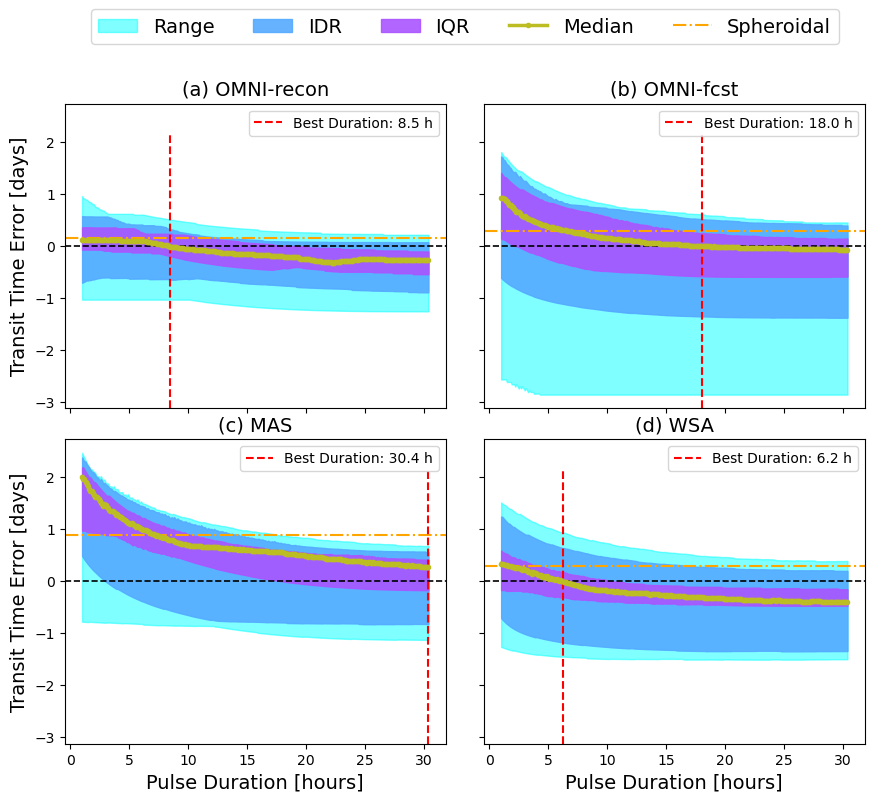

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)   # shared y-axis within each row

# =====================================================
# TRANSIT TIME ERRORS
# =====================================================

# ---------- OMNI recon ----------
plot_spread_bands(axes[0, 0], pulse_durations, median=recon_tt_median, sph_median=recon_tt_median_sph, q1=recon_tt_q1, 
                  q3=recon_tt_q3, d1=recon_tt_d1, d9=recon_tt_d9, vmin=recon_tt_min, vmax=recon_tt_max)

axes[0, 0].set_title('(a) OMNI-recon', fontsize=14)
axes[0, 0].set_ylabel('Transit Time Error [days]', fontsize=14)

# ---------- OMNI fcst ----------
plot_spread_bands(axes[0, 1], pulse_durations, median=tt_median, sph_median=tt_median_sph, q1=tt_q1, q3=tt_q3,
    d1=tt_d1, d9=tt_d9, vmin=tt_min, vmax=tt_max)

axes[0, 1].set_title('(b) OMNI-fcst', fontsize=14)

# ---------- MAS ----------
plot_spread_bands(axes[1, 0], pulse_durations, median=mas_tt_median, sph_median=mas_tt_median_sph, q1=mas_tt_q1, q3=mas_tt_q3,
    d1=mas_tt_d1, d9=mas_tt_d9, vmin=mas_tt_min, vmax=mas_tt_max)

axes[1, 0].set_title('(c) MAS', fontsize=14)
axes[1, 0].set_ylabel('Transit Time Error [days]', fontsize=14)
axes[1, 0].set_xlabel('Pulse Duration [hours]', fontsize=14)

# ---------- WSA ----------
plot_spread_bands(axes[1, 1], pulse_durations, median=wsa_tt_median, sph_median=wsa_tt_median_sph, q1=wsa_tt_q1, q3=wsa_tt_q3,
    d1=wsa_tt_d1, d9=wsa_tt_d9, vmin=wsa_tt_min, vmax=wsa_tt_max)

axes[1, 1].set_title('(d) WSA', fontsize=14)
axes[1, 1].set_xlabel('Pulse Duration [hours]', fontsize=14)

# =====================================================
# CREATE SHARED LEGEND (WITHOUT BEST DURATION)
# =====================================================

# Get all handles/labels from first axis
handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove "Best Duration" entries from shared legend
filtered = [(h, l)
    for h, l in zip(handles, labels)
    if "Best Duration" not in l
]

shared_handles, shared_labels = zip(*filtered)

# Remove duplicates while preserving order
seen = set()
unique_handles = []
unique_labels = []

for h, l in zip(shared_handles, shared_labels):
    if l not in seen:
        unique_handles.append(h)
        unique_labels.append(l)
        seen.add(l)

# Shared legend at top
fig.legend(unique_handles,unique_labels,loc='upper center',bbox_to_anchor=(0.5, 1.03),ncol=5,fontsize=14,frameon=True)

# =====================================================
# FINAL FORMATTING
# =====================================================
fig.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.1, hspace=0.1) # tighten spaces between subplots
filename = "/Users/dven/repos/Pulse_duration/surf/figures/analysis/error_bands_tt.pdf"

fig.savefig(filename, format="pdf", bbox_inches="tight")

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_19630/2189960630.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_19630/2189960630.py:26: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  rgba = copy.copy(mpl.cm.get_cmap(cmap)(norm(band_index)))
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_19630/2189960630.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()``

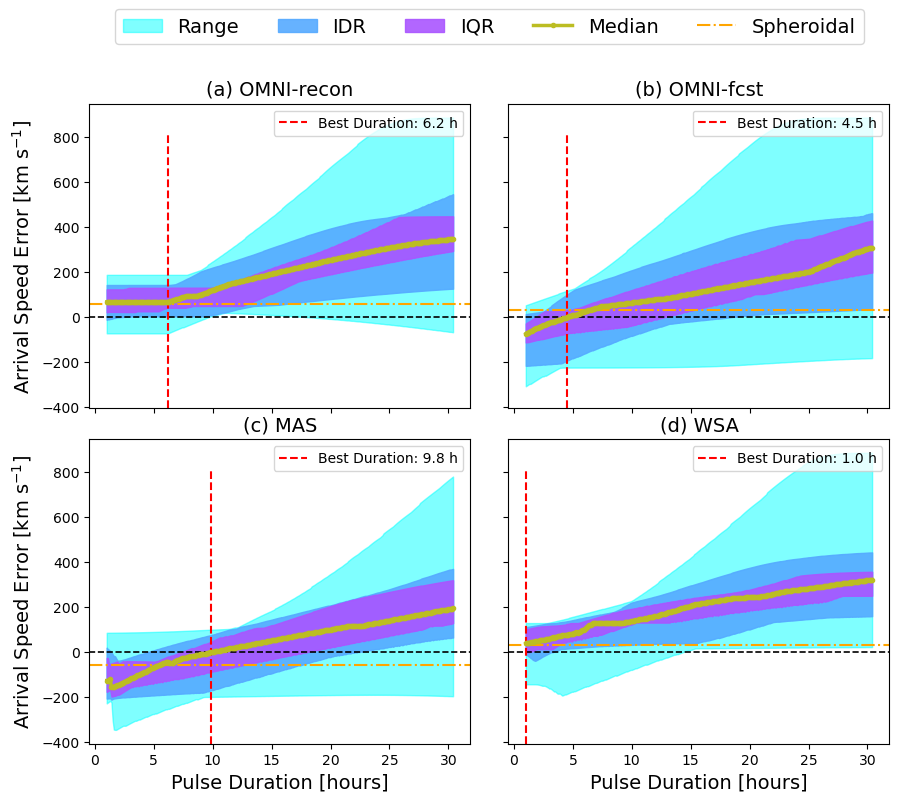

In [31]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)   # shared y-axis within each row

# =====================================================
# ARRIVAL SPEED ERRORS
# =====================================================

# ---------- OMNI recon ----------
plot_spread_bands(axes[0, 0], pulse_durations, median=recon_av_median, sph_median=recon_av_median_sph, q1=recon_av_q1, 
                  q3=recon_av_q3, d1=recon_av_d1, d9=recon_av_d9, vmin=recon_av_min, vmax=recon_av_max)

axes[0, 0].set_title('(a) OMNI-recon', fontsize=14)
axes[0, 0].set_ylabel(r'Arrival Speed Error [km s$^{-1}$]', fontsize=14)

# ---------- OMNI fcst ----------
plot_spread_bands(axes[0, 1], pulse_durations, median=av_median, sph_median=av_median_sph, q1=av_q1, q3=av_q3,
    d1=av_d1, d9=av_d9, vmin=av_min, vmax=av_max)

axes[0, 1].set_title('(b) OMNI-fcst', fontsize=14)

# ---------- MAS ----------
plot_spread_bands(axes[1, 0], pulse_durations, median=mas_av_median, sph_median=mas_av_median_sph, q1=mas_av_q1, q3=mas_av_q3,
    d1=mas_av_d1, d9=mas_av_d9, vmin=mas_av_min, vmax=mas_av_max)

axes[1, 0].set_title('(c) MAS', fontsize=14)
axes[1, 0].set_ylabel(r'Arrival Speed Error [km s$^{-1}$]', fontsize=14)
axes[1, 0].set_xlabel('Pulse Duration [hours]', fontsize=14)

# ---------- WSA ----------
plot_spread_bands(axes[1, 1],pulse_durations, median=wsa_av_median, sph_median=wsa_av_median_sph, q1=wsa_av_q1, q3=wsa_av_q3,
    d1=wsa_av_d1, d9=wsa_av_d9, vmin=wsa_av_min, vmax=wsa_av_max)

axes[1, 1].set_title('(d) WSA', fontsize=14)
axes[1, 1].set_xlabel('Pulse Duration [hours]', fontsize=14)

# =====================================================
# CREATE SHARED LEGEND (WITHOUT BEST DURATION)
# =====================================================

# Get all handles/labels from first axis
handles, labels = axes[0, 0].get_legend_handles_labels()

# Remove "Best Duration" entries from shared legend
filtered = [(h, l)
    for h, l in zip(handles, labels)
    if "Best Duration" not in l
]

shared_handles, shared_labels = zip(*filtered)

# Remove duplicates while preserving order
seen = set()
unique_handles = []
unique_labels = []

for h, l in zip(shared_handles, shared_labels):
    if l not in seen:
        unique_handles.append(h)
        unique_labels.append(l)
        seen.add(l)

# Shared legend at top
fig.legend(unique_handles,unique_labels,loc='upper center',bbox_to_anchor=(0.5, 1.03),ncol=5,fontsize=14,frameon=True)

# =====================================================
# FINAL FORMATTING
# =====================================================
fig.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9, wspace=0.1, hspace=0.1) # tighten spaces between subplots
filename = "/Users/dven/repos/Pulse_duration/surf/figures/analysis/error_bands_av.pdf"

fig.savefig(filename, format="pdf", bbox_inches="tight")

# Error distribution for each CME arranged by V, ang_width

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_27607/1614228093.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_27607/1614228093.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="v_cme", y="Error", data=df_melted, order=sorted(spread.index), palette=palette, ax=ax,
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_27607/1614228093.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()

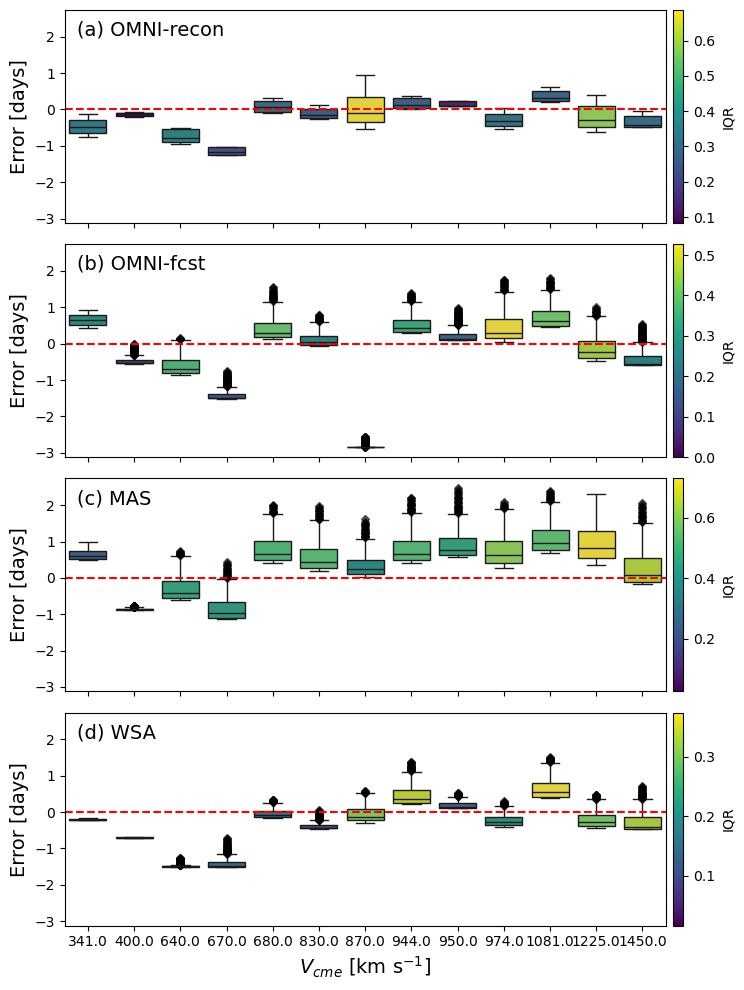

In [24]:
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True, sharey=True)

df_melted_tt_recon, spread_tt_recon = plot_v_error_boxplot(axes[0], recon_tt_error, v_cme, ylabel="Error [days]")

df_melted_tt, spread_tt = plot_v_error_boxplot(axes[1], tt_error, v_cme, ylabel="Error [days]")

df_melted_tt_mas, spread_tt_mas = plot_v_error_boxplot(axes[2], mas_tt_error, v_cme, ylabel="Error [days]")

df_melted_tt_wsa, spread_tt_wsa = plot_v_error_boxplot(axes[3], wsa_tt_error, v_cme, ylabel="Error [days]")

axes[2].tick_params(axis='x', labelrotation=45)

# ---- panel labels ----
labels = ["(a) OMNI-recon", "(b) OMNI-fcst", "(c) MAS", "(d) WSA"]
for ax, lab in zip(axes, labels):
    ax.text(0.02, 0.95, lab,
            transform=ax.transAxes,
            fontsize=14,
            va='top')

# ---- layout ----
fig.tight_layout(rect=[0, 0, 1, 1])

fig.subplots_adjust(hspace=0.1)

fig.savefig(
    "/Users/dven/repos/Pulse_duration/surf/figures/analysis/tt_error_vs_vcme.pdf",
    bbox_inches="tight"
)

/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_27607/1614228093.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_27607/1614228093.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="v_cme", y="Error", data=df_melted, order=sorted(spread.index), palette=palette, ax=ax,
/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_27607/1614228093.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()

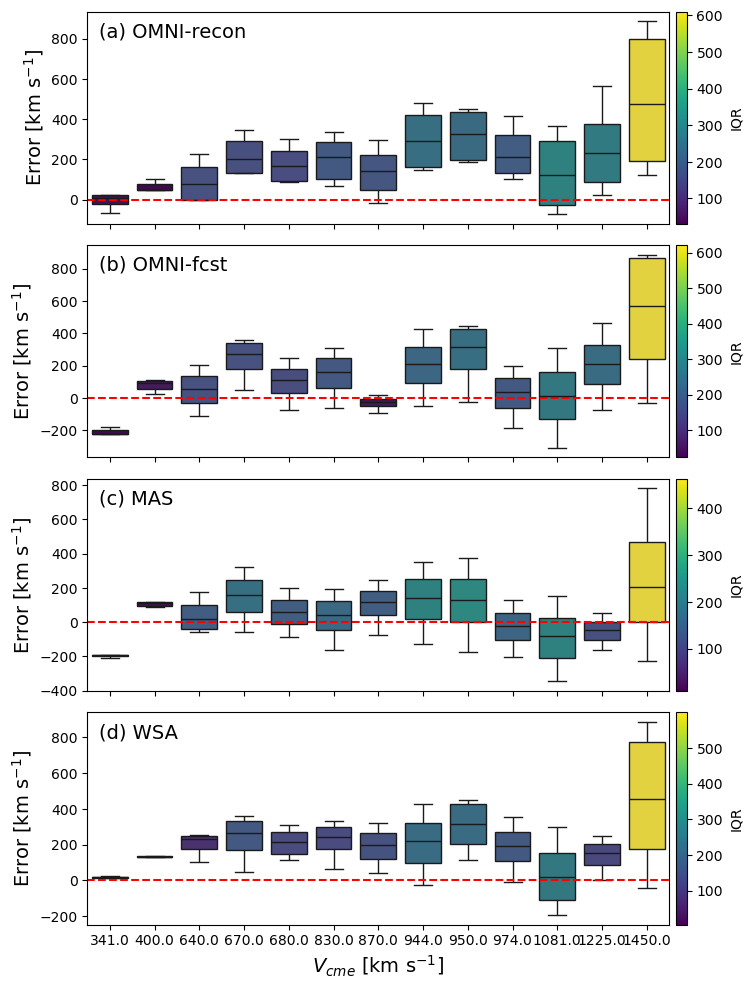

In [25]:
fig, axes = plt.subplots(4, 1, figsize=(8, 10), sharex=True)

df_melted_av_recon, spread_av_recon = plot_v_error_boxplot(axes[0], recon_av_error, v_cme, ylabel=r'Error [km s$^{-1}$]')

df_melted_av, spread_av = plot_v_error_boxplot(axes[1], av_error, v_cme, ylabel=r'Error [km s$^{-1}$]')

df_melted_av_mas, spread_av_mas = plot_v_error_boxplot(axes[2], mas_av_error, v_cme, ylabel=r'Error [km s$^{-1}$]')

df_melted_av_wsa, spread_av_wsa = plot_v_error_boxplot(axes[3], wsa_av_error, v_cme, ylabel=r'Error [km s$^{-1}$]')

axes[2].tick_params(axis='x', labelrotation=45)

# ---- panel labels ----
labels = ["(a) OMNI-recon", "(b) OMNI-fcst", "(c) MAS", "(d) WSA"]
for ax, lab in zip(axes, labels):
    ax.text(0.02, 0.95, lab,
            transform=ax.transAxes,
            fontsize=14,
            va='top')

# ---- layout ----
fig.tight_layout(rect=[0, 0, 1, 1])

fig.subplots_adjust(hspace=0.1)

fig.savefig(
    "/Users/dven/repos/Pulse_duration/surf/figures/analysis/av_error_vs_vcme.pdf",
    bbox_inches="tight"
)

# Spread of errors at optimal pulse duration

In [37]:
print(pulse_durations.iloc[75])

8.5


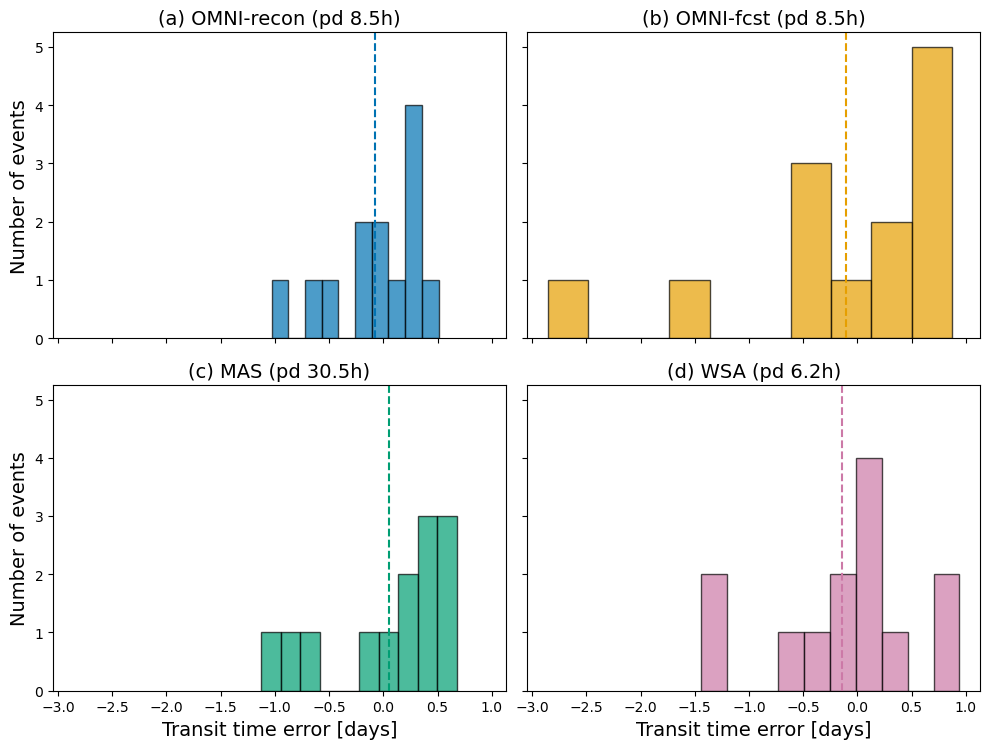

In [26]:
fig, ax = plt.subplots(2,2,figsize=(10, 8), sharey=True, sharex=True)

# define colours

c_omni_recon = "#0072B2"
c_omni_fcst = "#E69F00"
c_mas  = "#009E73"
c_wsa  = "#CC79A7"

# histograms
ax[0,0].hist(recon_tt_error.iloc[75, :], alpha=0.7, color=c_omni_recon, edgecolor='black')
ax[0,1].hist(tt_error.iloc[75, :], alpha=0.7, color=c_omni_fcst, edgecolor='black')
ax[1,0].hist(mas_tt_error.iloc[294, :], alpha=0.7, color=c_mas, edgecolor='black')
ax[1,1].hist(wsa_tt_error.iloc[52, :], alpha=0.7, color=c_wsa, edgecolor='black')

# means (same colours)
ax[0,0].axvline(np.mean(recon_tt_error.iloc[75, :]), color=c_omni_recon, linestyle='--')
ax[0,1].axvline(np.mean(tt_error.iloc[75, :]), color=c_omni_fcst, linestyle='--')
ax[1,0].axvline(np.mean(mas_tt_error.iloc[294, :]), color=c_mas, linestyle='--')
ax[1,1].axvline(np.mean(wsa_tt_error.iloc[52, :]), color=c_wsa, linestyle='--')

# labels and titles
ax[1,0].set_xlabel("Transit time error [days]", fontsize=14)
ax[1,1].set_xlabel("Transit time error [days]", fontsize=14)
ax[0,0].set_ylabel("Number of events", fontsize=14)
ax[1,0].set_ylabel("Number of events", fontsize=14)

ax[0, 0].set_title('(a) OMNI-recon (pd 8.5h)', fontsize=14)
ax[0, 1].set_title('(b) OMNI-fcst (pd 8.5h)', fontsize=14)
ax[1, 0].set_title('(c) MAS (pd 30.5h)', fontsize=14)
ax[1, 1].set_title('(d) WSA (pd 6.2h)', fontsize=14)

fig.tight_layout(rect=[0, 0, 1, 0.95])

filename = ("/Users/dven/repos/Pulse_duration/surf/figures/analysis/optimal_duration_error.pdf")
fig.savefig(filename, format="pdf", bbox_inches="tight")

Mean absolute error for OMNI-recon: 0.33334363862060196
Mean absolute error for OMNI-fcst: 0.7327159102767324
Mean absolute error for MAS: 0.4782819686489353
Mean absolute error for WSA: 0.481609143548697


/var/folders/ny/0p_7l18s37704rxbjw3bptmw0000gn/T/ipykernel_27607/511804166.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


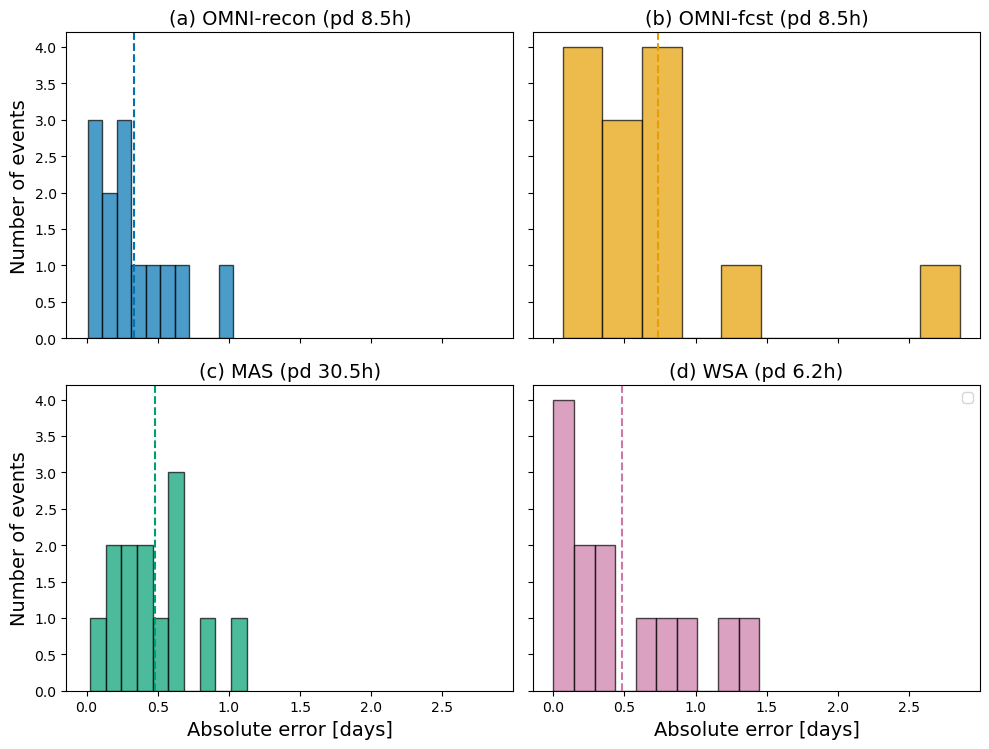

In [27]:
def abs_error():

    """ Plot absolute transit time errors at optimal pulse duration for different background winds"""

    fig, ax = plt.subplots(2,2,figsize=(10, 8), sharey=True, sharex=True)

    # define colours
    c_omni_recon = "#0072B2"
    c_omni_fcst = "#E69F00"
    c_mas  = "#009E73"
    c_wsa  = "#CC79A7"

    # calculate absolute errors and their means
    recon_omni = recon_tt_error.iloc[75, :].abs()
    mean_recon_omni = recon_omni.mean()

    omni = tt_error.iloc[75, :].abs()
    mean_omni = omni.mean()

    mas = mas_tt_error.iloc[294, :].abs()
    mean_mas = mas.mean()

    wsa = wsa_tt_error.iloc[52, :].abs()
    mean_wsa = wsa.mean()   

    # histograms

    ax[0,0].hist(recon_omni, alpha=0.7, color=c_omni_recon, edgecolor='black')
    ax[0,1].hist(omni, alpha=0.7, color=c_omni_fcst, edgecolor='black')
    ax[1,0].hist(mas, alpha=0.7, color=c_mas, edgecolor='black')
    ax[1,1].hist(wsa, alpha=0.7, color=c_wsa, edgecolor='black')

    # means (same colours)
    ax[0,0].axvline(mean_recon_omni, color=c_omni_recon, linestyle='--')
    ax[0,1].axvline(mean_omni, color=c_omni_fcst, linestyle='--')
    ax[1,0].axvline(mean_mas, color=c_mas, linestyle='--')
    ax[1,1].axvline(mean_wsa, color=c_wsa, linestyle='--')

    # labels and titles
    ax[1,0].set_xlabel("Absolute error [days]", fontsize=14)
    ax[1,1].set_xlabel("Absolute error [days]", fontsize=14)
    ax[0,0].set_ylabel("Number of events", fontsize=14)
    ax[1,0].set_ylabel("Number of events", fontsize=14)

    ax[0, 0].set_title('(a) OMNI-recon (pd 8.5h)', fontsize=14)
    ax[0, 1].set_title('(b) OMNI-fcst (pd 8.5h)', fontsize=14)
    ax[1, 0].set_title('(c) MAS (pd 30.5h)', fontsize=14)
    ax[1, 1].set_title('(d) WSA (pd 6.2h)', fontsize=14)

    fig.tight_layout(rect=[0, 0, 1, 0.95])

    print('Mean absolute error for OMNI-recon:', mean_recon_omni)
    print('Mean absolute error for OMNI-fcst:', mean_omni)
    print('Mean absolute error for MAS:', mean_mas)
    print('Mean absolute error for WSA:', mean_wsa)

    plt.legend()
    plt.savefig("/Users/dven/repos/Pulse_duration/surf/figures/analysis/absolute_error.pdf", format="pdf", bbox_inches="tight")

abs_error()